Test files with deltas

In [1]:
import h5ify
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

from models import BrokenPowerlawPlusTwoPeaks_PrimaryMass_FullSmooth
from models import iso_gauss_spin_tilt
from models import log_powerlaw_redshift
from models import truncnorm
from pixelpop.models.gwpop_models import PowerlawPlusPeak_MassRatio

from likelihood import get_bilby_likelihood

%load_ext autoreload
%autoreload 2

/home/noah.wolfe/.conda/envs/seqpop/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from vt import concat
concat('../../data/vt/xp', load_all=True)

100%|██████████| 993/993 [01:03<00:00, 15.74it/s]


ValueError: Unable to synchronously create group (name already exists)

In [3]:
concat('../../data/vt/xp', load_all=False)

100%|██████████| 992/992 [00:14<00:00, 69.53it/s]


In [4]:
detectable = h5ify.load('../../data/vt/xp/detectable.hdf5')
ndet = len(detectable['log_prior'])

detectable['prior'] = jnp.exp(detectable.pop('log_prior'))

In [5]:
allinjs = h5ify.load('../../data/vt/xp/all.hdf5')

In [16]:
import json

with open(f'./parameters/vt-o4a-strong-maxl-sharp-peak.json', 'r') as f:
    truths = json.loads(f.read())
truths.pop('z_max')
truths.pop('lam_2')
truths.pop('mmax')

300.0

In [20]:
truths['mlow_1']

3.56

In [25]:

allinjs['mass_1_source'].min()

np.float64(4.012267479371679)

(1e-06, 1.0)

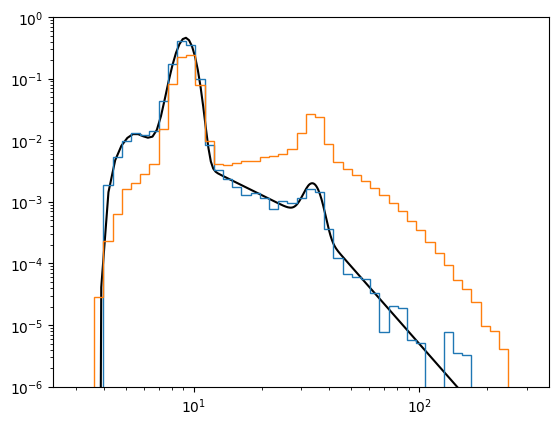

In [27]:
test_m1s = jnp.linspace(3, 300, 1000)

log_p_m1 = BrokenPowerlawPlusTwoPeaks_PrimaryMass_FullSmooth(
    test_m1s,
    alpha_1=truths['alpha_1'],
    alpha_2=truths['alpha_2'],
    mlow_1=truths['mlow_1'],
    break_mass=truths['break_mass'],
    delta_m_1=truths['delta_m_1'],
    lam_fractions=(
        truths['lam_0'], truths['lam_1'], (1 - truths['lam_1'] - truths['lam_0'])
    ),
    mpp_1=truths['mpp_1'],
    sigpp_1=truths['sigpp_1'],
    mpp_2=truths['mpp_2'],
    sigpp_2=truths['sigpp_2'],
    mmax=300.0,
    gaussian_mass_maximum=100.0
)

fig, ax = plt.subplots()
ax.plot(
    test_m1s,
    jnp.exp(log_p_m1),
    linestyle='-',
    color='black'
)
ax.hist(allinjs['mass_1_source'], histtype='step', bins=jnp.logspace(jnp.log10(3), jnp.log10(300), 50), density=True);
ax.hist(detectable['mass_1_source'], histtype='step', bins=jnp.logspace(jnp.log10(3), jnp.log10(300), 50), density=True);
ax.loglog()
ax.set_ylim(1e-6, 1e0)

In [28]:
nobs = 350
idxs = jax.random.choice(jax.random.key(42), ndet, shape=(nobs,), replace=False)
idxs = jnp.sort(idxs)

In [30]:
from copy import deepcopy
posteriors = deepcopy(detectable)
posteriors.pop('attrs')
posteriors.pop('total_generated')
posteriors.pop('model')
posteriors.pop('parameters')
posteriors['mass_1'] = posteriors.pop('mass_1_source')
posteriors = {k : v[idxs].reshape(nobs, 1) for k, v in posteriors.items()}

In [31]:
injections = deepcopy(detectable)
injections['mass_1'] = injections.pop('mass_1_source')

In [32]:
def model(dataset, parameters):
    if 'lam_2' not in parameters:
        lam_2 = 1 - parameters['lam_1'] - parameters['lam_0']
    else:
        lam_2 = parameters['lam_2']

    log_p_m1 = BrokenPowerlawPlusTwoPeaks_PrimaryMass_FullSmooth(
        dataset['mass_1'],
        alpha_1=parameters['alpha_1'],
        alpha_2=parameters['alpha_2'],
        mlow_1=parameters['mlow_1'],
        break_mass=parameters['break_mass'],
        delta_m_1=parameters['delta_m_1'],
        lam_fractions=(
            parameters['lam_0'], parameters['lam_1'], lam_2
        ),
        mpp_1=parameters['mpp_1'],
        sigpp_1=parameters['sigpp_1'],
        mpp_2=parameters['mpp_2'],
        sigpp_2=parameters['sigpp_2'],
        mmax=300.0,
        gaussian_mass_maximum=100.0
    )

    log_p_q = PowerlawPlusPeak_MassRatio(
        dataset,
        slope=parameters['beta'],
        minimum=parameters['mlow_1'],
        delta_m=parameters['delta_m_1']
    )

    log_p_z = log_powerlaw_redshift(dataset, parameters)


    p_a1 = truncnorm(
        dataset['a_1'],
        parameters['mu_chi'],
        parameters['sigma_chi'],
        high=1,
        low=0
    )
    p_a2 = truncnorm(
        dataset['a_2'],
        parameters['mu_chi'],
        parameters['sigma_chi'],
        high=1,
        low=0
    )

    sigma_spin = jnp.exp(parameters['log_sigma_spin'])
    p_tau = iso_gauss_spin_tilt(
        dataset,
        xi_spin=parameters['xi_spin'],
        sigma_spin=sigma_spin,
        mu_spin=parameters['mu_spin']
    )

    return jnp.exp(log_p_m1) * jnp.exp(log_p_q) * jnp.exp(log_p_z) * p_a1 * p_a2 * p_tau

In [33]:
maximum_variance = 1

def taper(v):
    """ taper but actually it doesn't do anything! """
    return jnp.nan_to_num(-jnp.inf * (v >= maximum_variance))

likelihood = get_bilby_likelihood(
    model,
    posteriors,
    detectable,
    taper=taper,
    rate=False
)

In [34]:
from bilby.core.prior import ConditionalPriorDict

priors = ConditionalPriorDict('./priors/lvk-lnsigma.prior')

In [8]:
from bilby import run_sampler

outdir = '../../data/runs/vt-xp-delta-test'

result = run_sampler(
    likelihood=likelihood,
    priors=priors,
    outdir=outdir,
    sampler='dynesty',
    sample='acceptance-walk',
    naccept=5,
    nlive=50,
)

13:01 bilby INFO    : Running for label 'label', output will be saved to '../../data/runs/vt-xp-delta-test'
13:01 bilby INFO    : Analysis priors:
13:01 bilby INFO    : alpha_1=Uniform(minimum=-4, maximum=12, name=None, latex_label=None, unit=None, boundary=None)
13:01 bilby INFO    : alpha_2=Uniform(minimum=-4, maximum=12, name=None, latex_label=None, unit=None, boundary=None)
13:01 bilby INFO    : break_mass=Uniform(minimum=20, maximum=50, name=None, latex_label=None, unit=None, boundary=None)
13:01 bilby INFO    : mpp_1=Uniform(minimum=5, maximum=20, name=None, latex_label=None, unit=None, boundary=None)
13:01 bilby INFO    : sigpp_1=Uniform(minimum=0, maximum=10, name=None, latex_label=None, unit=None, boundary=None)
13:01 bilby INFO    : mpp_2=Uniform(minimum=25, maximum=60, name=None, latex_label=None, unit=None, boundary=None)
13:01 bilby INFO    : sigpp_2=Uniform(minimum=0, maximum=10, name=None, latex_label=None, unit=None, boundary=None)
13:01 bilby INFO    : delta_m_1=Unifor

15it [00:00, 123.88it/s, bound:0 nc:  7 ncall:7.9e+01 eff:19.0% logz-ratio=-3457.88+/-0.31 dlogz:2.72e+03>0.1]

/home/noah.wolfe/.conda/envs/seqpop/lib/python3.11/site-packages/dynesty/sampler.py:752: RuntimeWarning: overflow encountered in cast
  np.max(self.live_logl) + logvol - logz)
/home/noah.wolfe/.conda/envs/seqpop/lib/python3.11/site-packages/dynesty/utils.py:1350: RuntimeWarning: overflow encountered in cast
  logwt = np.logaddexp(loglstar_new, loglstar) + logdvol  # weight


117it [00:04, 10.95it/s, bound:1 nc: 10 ncall:1.2e+03 eff:9.7% logz-ratio=-2069.41+/-0.34 dlogz:1.23e+03>0.1] 

/home/noah.wolfe/.conda/envs/seqpop/lib/python3.11/site-packages/dynesty/sampler.py:320: RuntimeWarning: overflow encountered in cast
  if loglstar == _LOWL_VAL:


3541it [04:35, 14.21it/s, bound:114 nc: 17 ncall:7.1e+04 eff:5.0% logz-ratio=20.16+/-1.11 dlogz:0.104>0.1]   

13:05 bilby INFO    : Written checkpoint file ../../data/runs/vt-xp-delta-test/label_resume.pickle


3542it [04:43, 12.51it/s, bound:114 nc:  1 ncall:7.1e+04 eff:5.1% logz-ratio=20.20+/-1.12 dlogz:0.00198>0.1]

13:06 bilby INFO    : Rejection sampling nested samples to obtain 335 posterior samples
13:06 bilby INFO    : Sampling time: 0:04:43.141835
13:06 bilby WARNING : Result.save_to_file called with extension=True. This will default to json, and ignore the extension from the filename. This behaviour is deprecated and will be removed. 
13:06 bilby WARNING : Result.save_to_file called with extension=True. This will default to json, and ignore the extension from the filename. This behaviour is deprecated and will be removed. 


13:06 bilby INFO    : Summary of results:
nsamples: 335
ln_noise_evidence:    nan
ln_evidence:    nan +/-  1.228
ln_bayes_factor: 20.197 +/-  1.228



In [9]:
import json

with open(f'./parameters/vt-o4a-strong-maxl-sharp-peak.json', 'r') as f:
    truths = json.loads(f.read())
truths.pop('z_max')
truths.pop('lam_2')
truths.pop('mmax')

300.0

In [11]:
truths['log_sigma_spin'] = jnp.log(truths.pop('sigma_spin'))

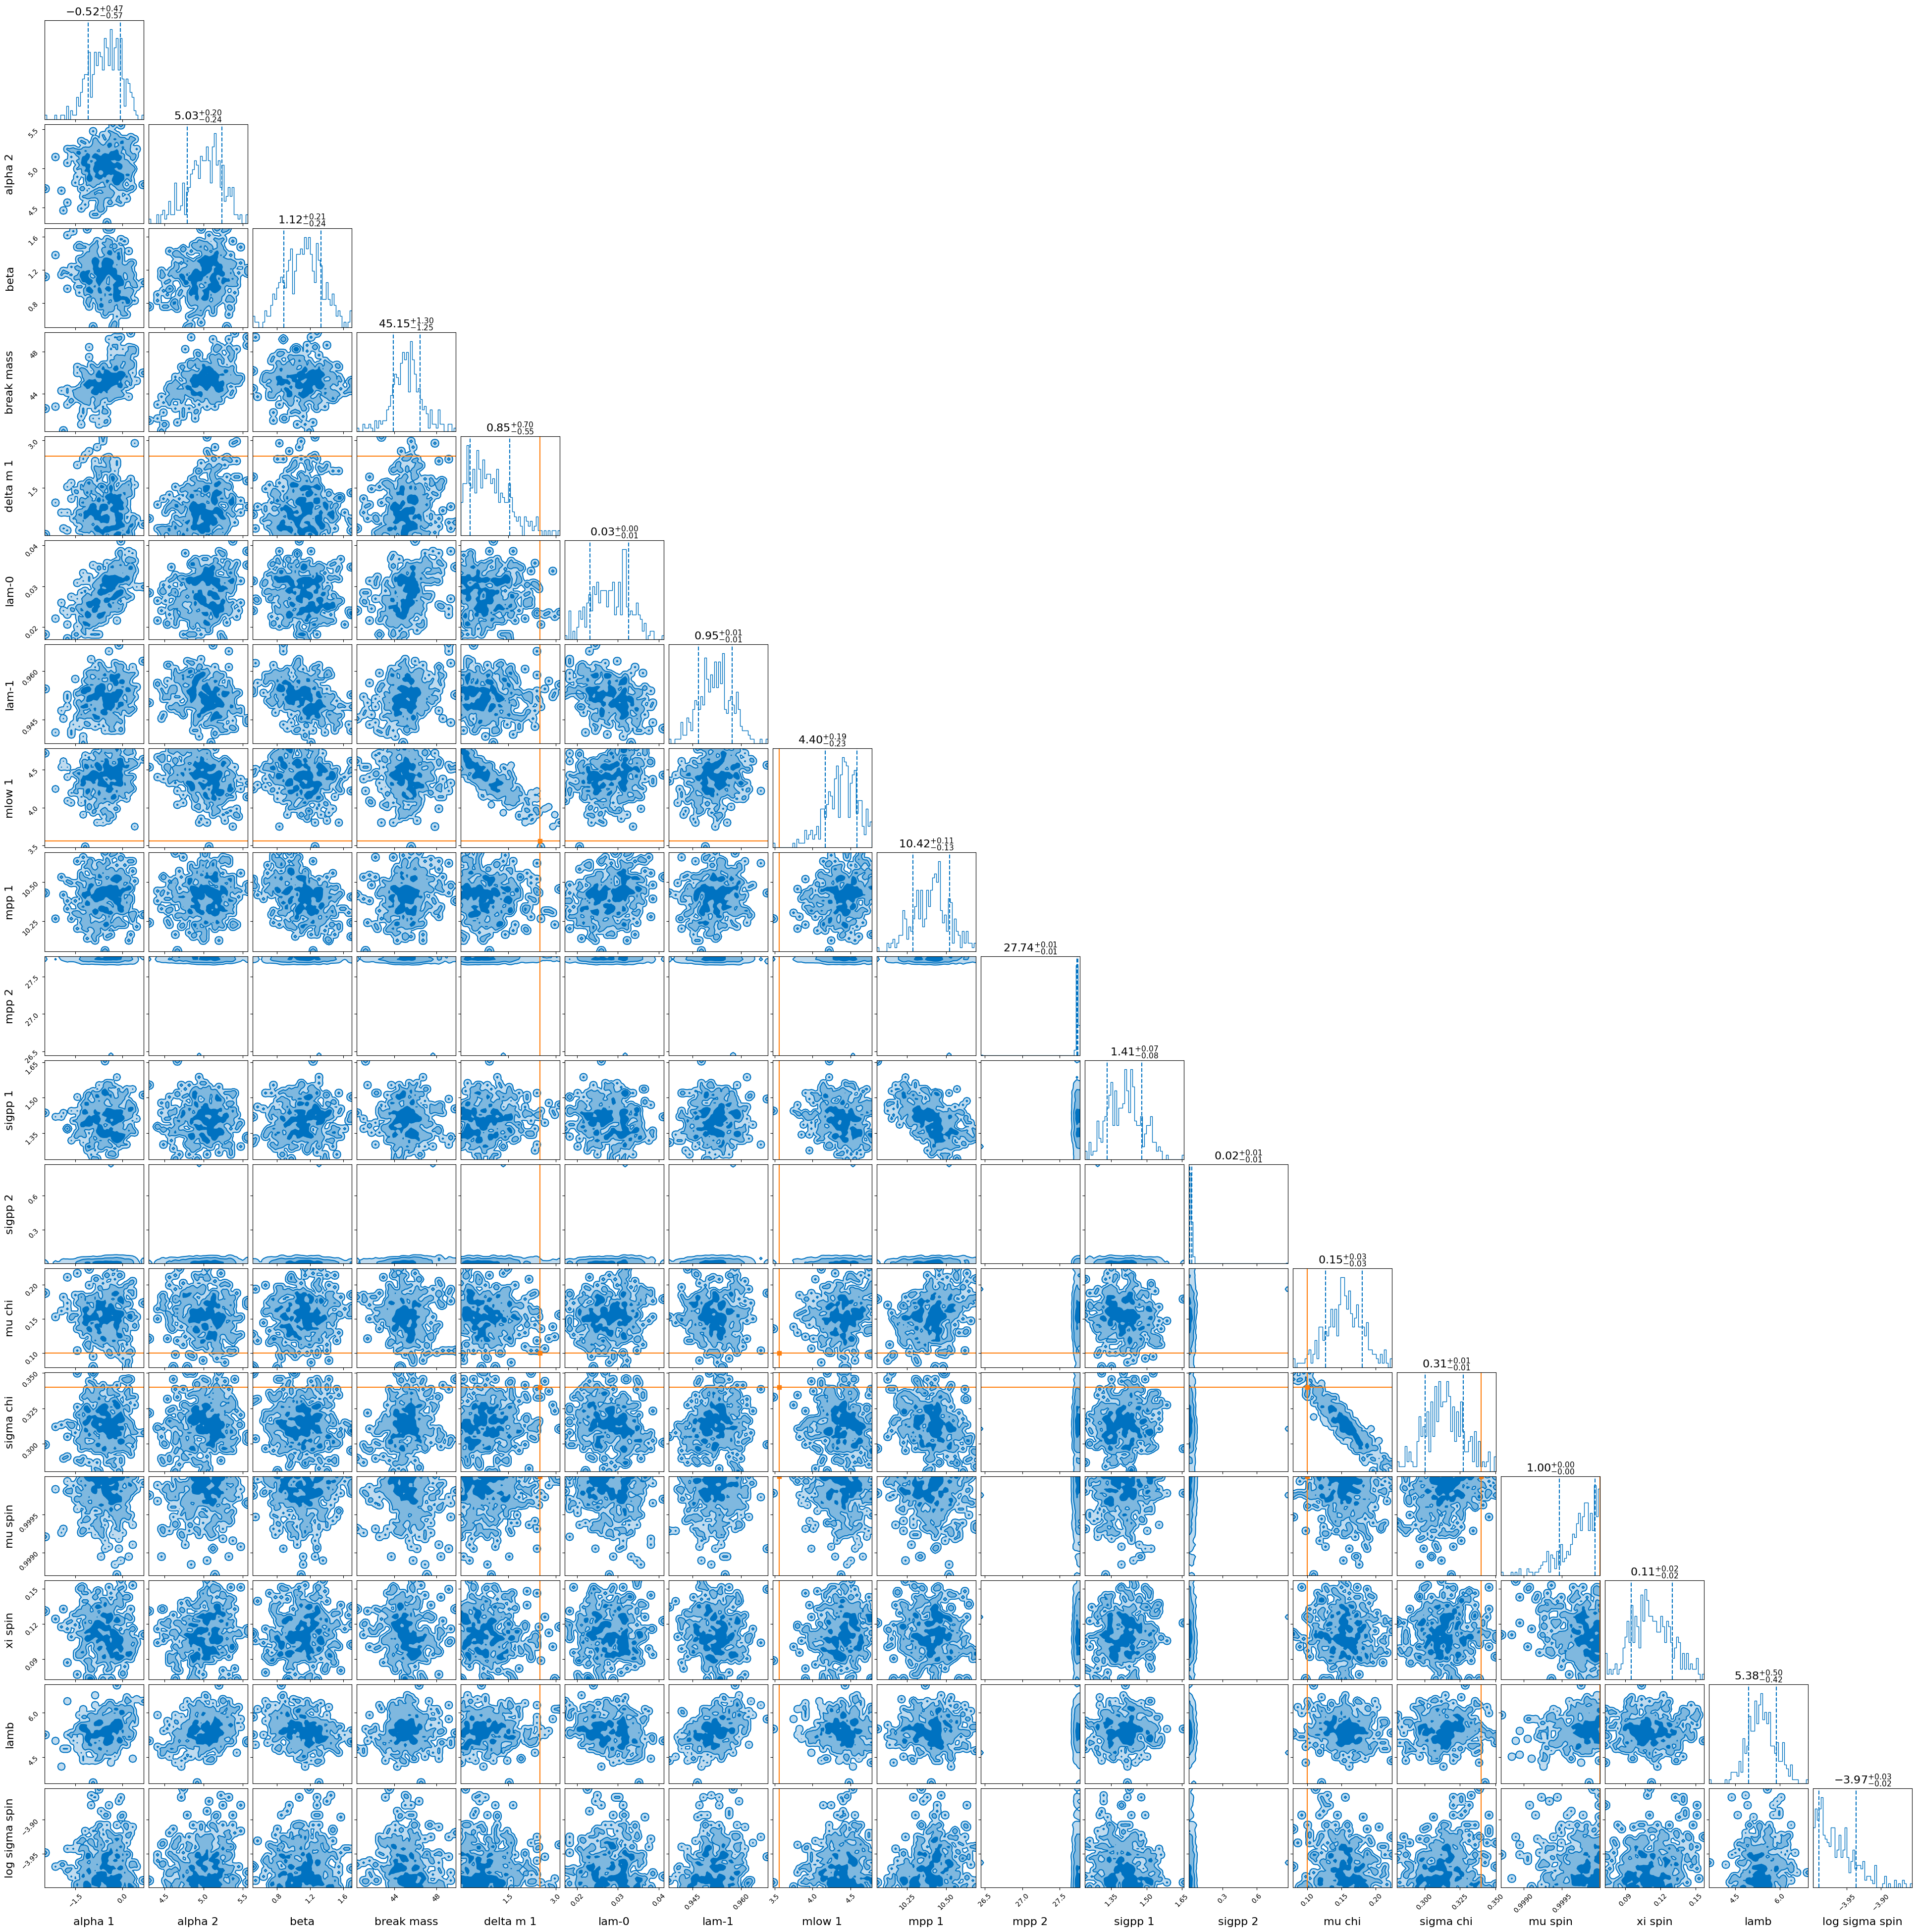

In [12]:
result.plot_corner(truths=truths)